In [1]:
import sys
import xarray as xr
import numpy as np
import pandas as pd
import math
import glob
import geopandas as gpd

import cartopy
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from matplotlib.gridspec import GridSpec
from matplotlib.colorbar import Colorbar # different way to handle colorbar

# cartopy
import cartopy.crs as ccrs
from cartopy.mpl.geoaxes import GeoAxes
import cartopy.feature as cfeature
import dask

# import personal modules
# Path to modules
sys.path.append('../modules')
# Import my modules
from utils import roundPartial
from plotter import draw_basemap, plot_terrain, plot_sensitivity_cbar
from trajectory import calculate_backward_trajectory
import customcmaps as ccmaps

dask.config.set(**{'array.slicing.split_large_chunks': True})

ERROR 1: PROJ: proj_create_from_database: Open of /home/dnash/miniconda3/envs/SEAK-impacts/share/proj failed


In [2]:
## what was the starting pressure at the site for each of these storms?


In [3]:
HUC8_lst = [14050001, ## upper yampa
               14030002, ## upper dolores
               10190002, ## 'Upper South Platte'
               11020001 ## Arkansas Headwaters
              ]

HUC8_lbl = ['Upper Yampa', 'Upper Dolores', 'Upper South Platte', 'Arkansas Headwaters']
ds_lst = []
## loop through all HUC8s
for i, HUC8_ID in enumerate(HUC8_lst):
    fname = '/expanse/nfs/cw3e/cwp140/preprocessed/ERA5_trajectories/sensitivity_tests/PRISM_HUC8_{0}.nc'.format(HUC8_ID)
    ds = xr.open_dataset(fname)
    ds = ds.assign(grid=['center', 'east', 'north', 'south', 'west'])
    ds_lst.append(ds)

ds = xr.concat(ds_lst, pd.Index(HUC8_lst, name="HUC8"))
ds

<xarray.Dataset>
Dimensions:       (start_lev: 4, start_date: 40, index: 72, grid: 5, HUC8: 4)
Coordinates:
  * start_lev     (start_lev) float64 500.0 600.0 700.0 800.0
  * start_date    (start_date) datetime64[ns] 2003-03-17 ... 2019-03-14T18:00:00
  * index         (index) int64 0 1 2 3 4 5 6 7 8 ... 63 64 65 66 67 68 69 70 71
  * grid          (grid) <U6 'center' 'east' 'north' 'south' 'west'
  * HUC8          (HUC8) int64 14050001 14030002 10190002 11020001
Data variables:
    time          (HUC8, start_lev, grid, start_date, index) datetime64[ns] 2...
    latitude      (HUC8, start_lev, grid, start_date, index) float64 40.45 .....
    longitude     (HUC8, start_lev, grid, start_date, index) float64 -107.1 ....
    level         (HUC8, start_lev, grid, start_date, index) float64 500.0 .....
    q             (HUC8, start_lev, grid, start_date, index) float64 1.349 .....
    u             (HUC8, start_lev, grid, start_date, index) float64 5.085 .....
    v             (HUC8, start_lev, grid, start_date, index) float64 8.518 .....
    w             (HUC8, start_lev, grid, start_date, index) float64 -0.3193 ...
    dq            (HUC8, start_lev, grid, start_date, index) float64 nan ... nan
    drying_ratio  (HUC8, start_lev, grid, start_date, index) float64 nan ... nan

In [4]:
## Load subbasin watershed file
path_to_data = '/expanse/nfs/cw3e/cwp140/'
fp = path_to_data + 'downloads/CO_HUC8/wbdhu8.shp'
polys = gpd.read_file(fp, crs="epsg:4326") # have to manually set the projection


idx = (polys.HUC8 == str(HUC8_lst[0])) | (polys.HUC8 == str(HUC8_lst[1])) | (polys.HUC8 == str(HUC8_lst[2])) | (polys.HUC8 == str(HUC8_lst[3]))
polys =  polys[idx]
polys

,OBJECTID,TNMID,MetaSource,SourceData,SourceOrig,SourceFeat,LoadDate,GNIS_ID,AreaAcres,AreaSqKm,States,HUC8,Name,Shape_Leng,Shape_Area,geometry
20,21,{E174065A-2AA4-49D1-B443-F550A60C869D},None,None,None,None,2016-07-27,0,1676731.25,6785.50,CO,14050001,Upper Yampa,5.099447,0.720391,"POLYGON ((-106.77828 40.90596, -106.77765 40.9..."
49,50,{19D18F78-BA7C-4A1E-A1F6-DA996B233880},None,None,None,None,2017-04-17,0,1961578.79,7938.23,CO,11020001,Arkansas Headwaters,7.020383,0.821013,"POLYGON ((-106.21421 39.38309, -106.21368 39.3..."
83,84,{4715E85E-95AB-43D1-B2BE-D913416DC714},None,None,None,None,2012-06-11,0,1380772.61,5587.79,"CO,UT",14030002,Upper Dolores,5.787294,0.572376,"POLYGON ((-109.06388 38.46306, -109.06337 38.4..."
87,88,{AAFC1326-6A7C-49C0-BC17-9573AE42BC21},None,None,None,None,2016-10-11,0,1183831.16,4790.80,CO,10190002,Upper South Platte,4.288653,0.500925,"POLYGON ((-105.04506 39.76261, -105.04449 39.7..."


In [5]:
storm = 'mar2003'
if storm == 'mar2003':
    tmp = ds.sel(start_date=slice('2003-03-18 12', '2003-03-19 06'))
    yr = '2003'
    mon = '03'
elif storm == 'mar2019':
    tmp = ds.sel(start_date=slice('2019-03-13 12', '2019-03-14  06'))
    yr = '2019'
    mon = '03'
elif storm == 'jan2017':
    tmp = ds.sel(start_date=slice('2017-01-09 12', '2019-01-10  06'))
    yr = '2017'
    mon = '01'
elif storm == 'sept2013':
    tmp = ds.sel(start_date=slice('2013-09-10 12', '2019-09-11  06'))
    yr = '2013'
    mon = '09'
tmp

<xarray.Dataset>
Dimensions:       (start_lev: 4, start_date: 4, index: 72, grid: 5, HUC8: 4)
Coordinates:
  * start_lev     (start_lev) float64 500.0 600.0 700.0 800.0
  * start_date    (start_date) datetime64[ns] 2003-03-18T12:00:00 ... 2003-03...
  * index         (index) int64 0 1 2 3 4 5 6 7 8 ... 63 64 65 66 67 68 69 70 71
  * grid          (grid) <U6 'center' 'east' 'north' 'south' 'west'
  * HUC8          (HUC8) int64 14050001 14030002 10190002 11020001
Data variables:
    time          (HUC8, start_lev, grid, start_date, index) datetime64[ns] 2...
    latitude      (HUC8, start_lev, grid, start_date, index) float64 40.45 .....
    longitude     (HUC8, start_lev, grid, start_date, index) float64 -107.1 ....
    level         (HUC8, start_lev, grid, start_date, index) float64 500.0 .....
    q             (HUC8, start_lev, grid, start_date, index) float64 1.335 .....
    u             (HUC8, start_lev, grid, start_date, index) float64 -16.37 ....
    v             (HUC8, start_lev, grid, start_date, index) float64 -5.18 .....
    w             (HUC8, start_lev, grid, start_date, index) float64 -0.2447 ...
    dq            (HUC8, start_lev, grid, start_date, index) float64 nan ... ...
    drying_ratio  (HUC8, start_lev, grid, start_date, index) float64 nan ... ...

In [6]:
## load geopotential height data
fname = path_to_data + 'downloads/ERA5/{0}{1}_z_prs.nc'.format(yr, mon)
gph = xr.open_dataset(fname)
gph

<xarray.Dataset>
Dimensions:         (valid_time: 12, pressure_level: 4, latitude: 721,
                     longitude: 1440)
Coordinates:
    number          int64 ...
  * valid_time      (valid_time) datetime64[ns] 2003-03-17 ... 2003-03-19T18:...
  * pressure_level  (pressure_level) float64 800.0 700.0 600.0 500.0
  * latitude        (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude       (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver          (valid_time) <U4 ...
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-10-18T21:11 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
gph.isel(valid_time=0, pressure_level=3).z.values/10

array([[4945.6475, 4945.6475, 4945.6475, ..., 4945.6475, 4945.6475,
        4945.6475],
       [4941.4976, 4941.4478, 4941.3975, ..., 4941.6226, 4941.5728,
        4941.5225],
       [4937.6226, 4937.548 , 4937.4478, ..., 4937.8726, 4937.798 ,
        4937.6978],
       ...,
       [4830.0225, 4830.048 , 4830.048 , ..., 4829.9976, 4829.9976,
        4830.0225],
       [4831.9976, 4831.9976, 4831.9976, ..., 4831.9727, 4831.9727,
        4831.9976],
       [4833.923 , 4833.923 , 4833.923 , ..., 4833.923 , 4833.923 ,
        4833.923 ]], dtype=float32)

In [8]:
## create tick labels 'YYYY-MM-DD HH'
t_lst = []
for m, start_date_val in enumerate(tmp.start_date.values):
    ts = pd.to_datetime(str(start_date_val)) 
    t = ts.strftime('%Y-%m-%d %H UTC')
    t_lst.append(t)
# ["{:.0%}".format(i) for i in cbax.get_ticks()]
t_lst

['2003-03-18 12 UTC',
 '2003-03-18 18 UTC',
 '2003-03-19 00 UTC',
 '2003-03-19 06 UTC']

In [9]:
letter_lst = list(map(chr, range(97, 123)))
title_list = []
for i, col in enumerate(np.arange(0,16, 4)):
    for j, row in enumerate(np.arange(0,4,1)):
        print(i, j)
        titlestring = '({0})'.format(letter_lst[col+j])
        print(titlestring)

0 0
(a)
0 1
(b)
0 2
(c)
0 3
(d)
1 0
(e)
1 1
(f)
1 2
(g)
1 3
(h)
2 0
(i)
2 1
(j)
2 2
(k)
2 3
(l)
3 0
(m)
3 1
(n)
3 2
(o)
3 3
(p)


0 0 500.0
0 1 600.0
0 2 700.0
0 3 800.0
1 0 500.0
1 1 600.0
1 2 700.0
1 3 800.0
2 0 500.0
2 1 600.0
2 2 700.0
2 3 800.0
3 0 500.0
3 1 600.0
3 2 700.0
3 3 800.0


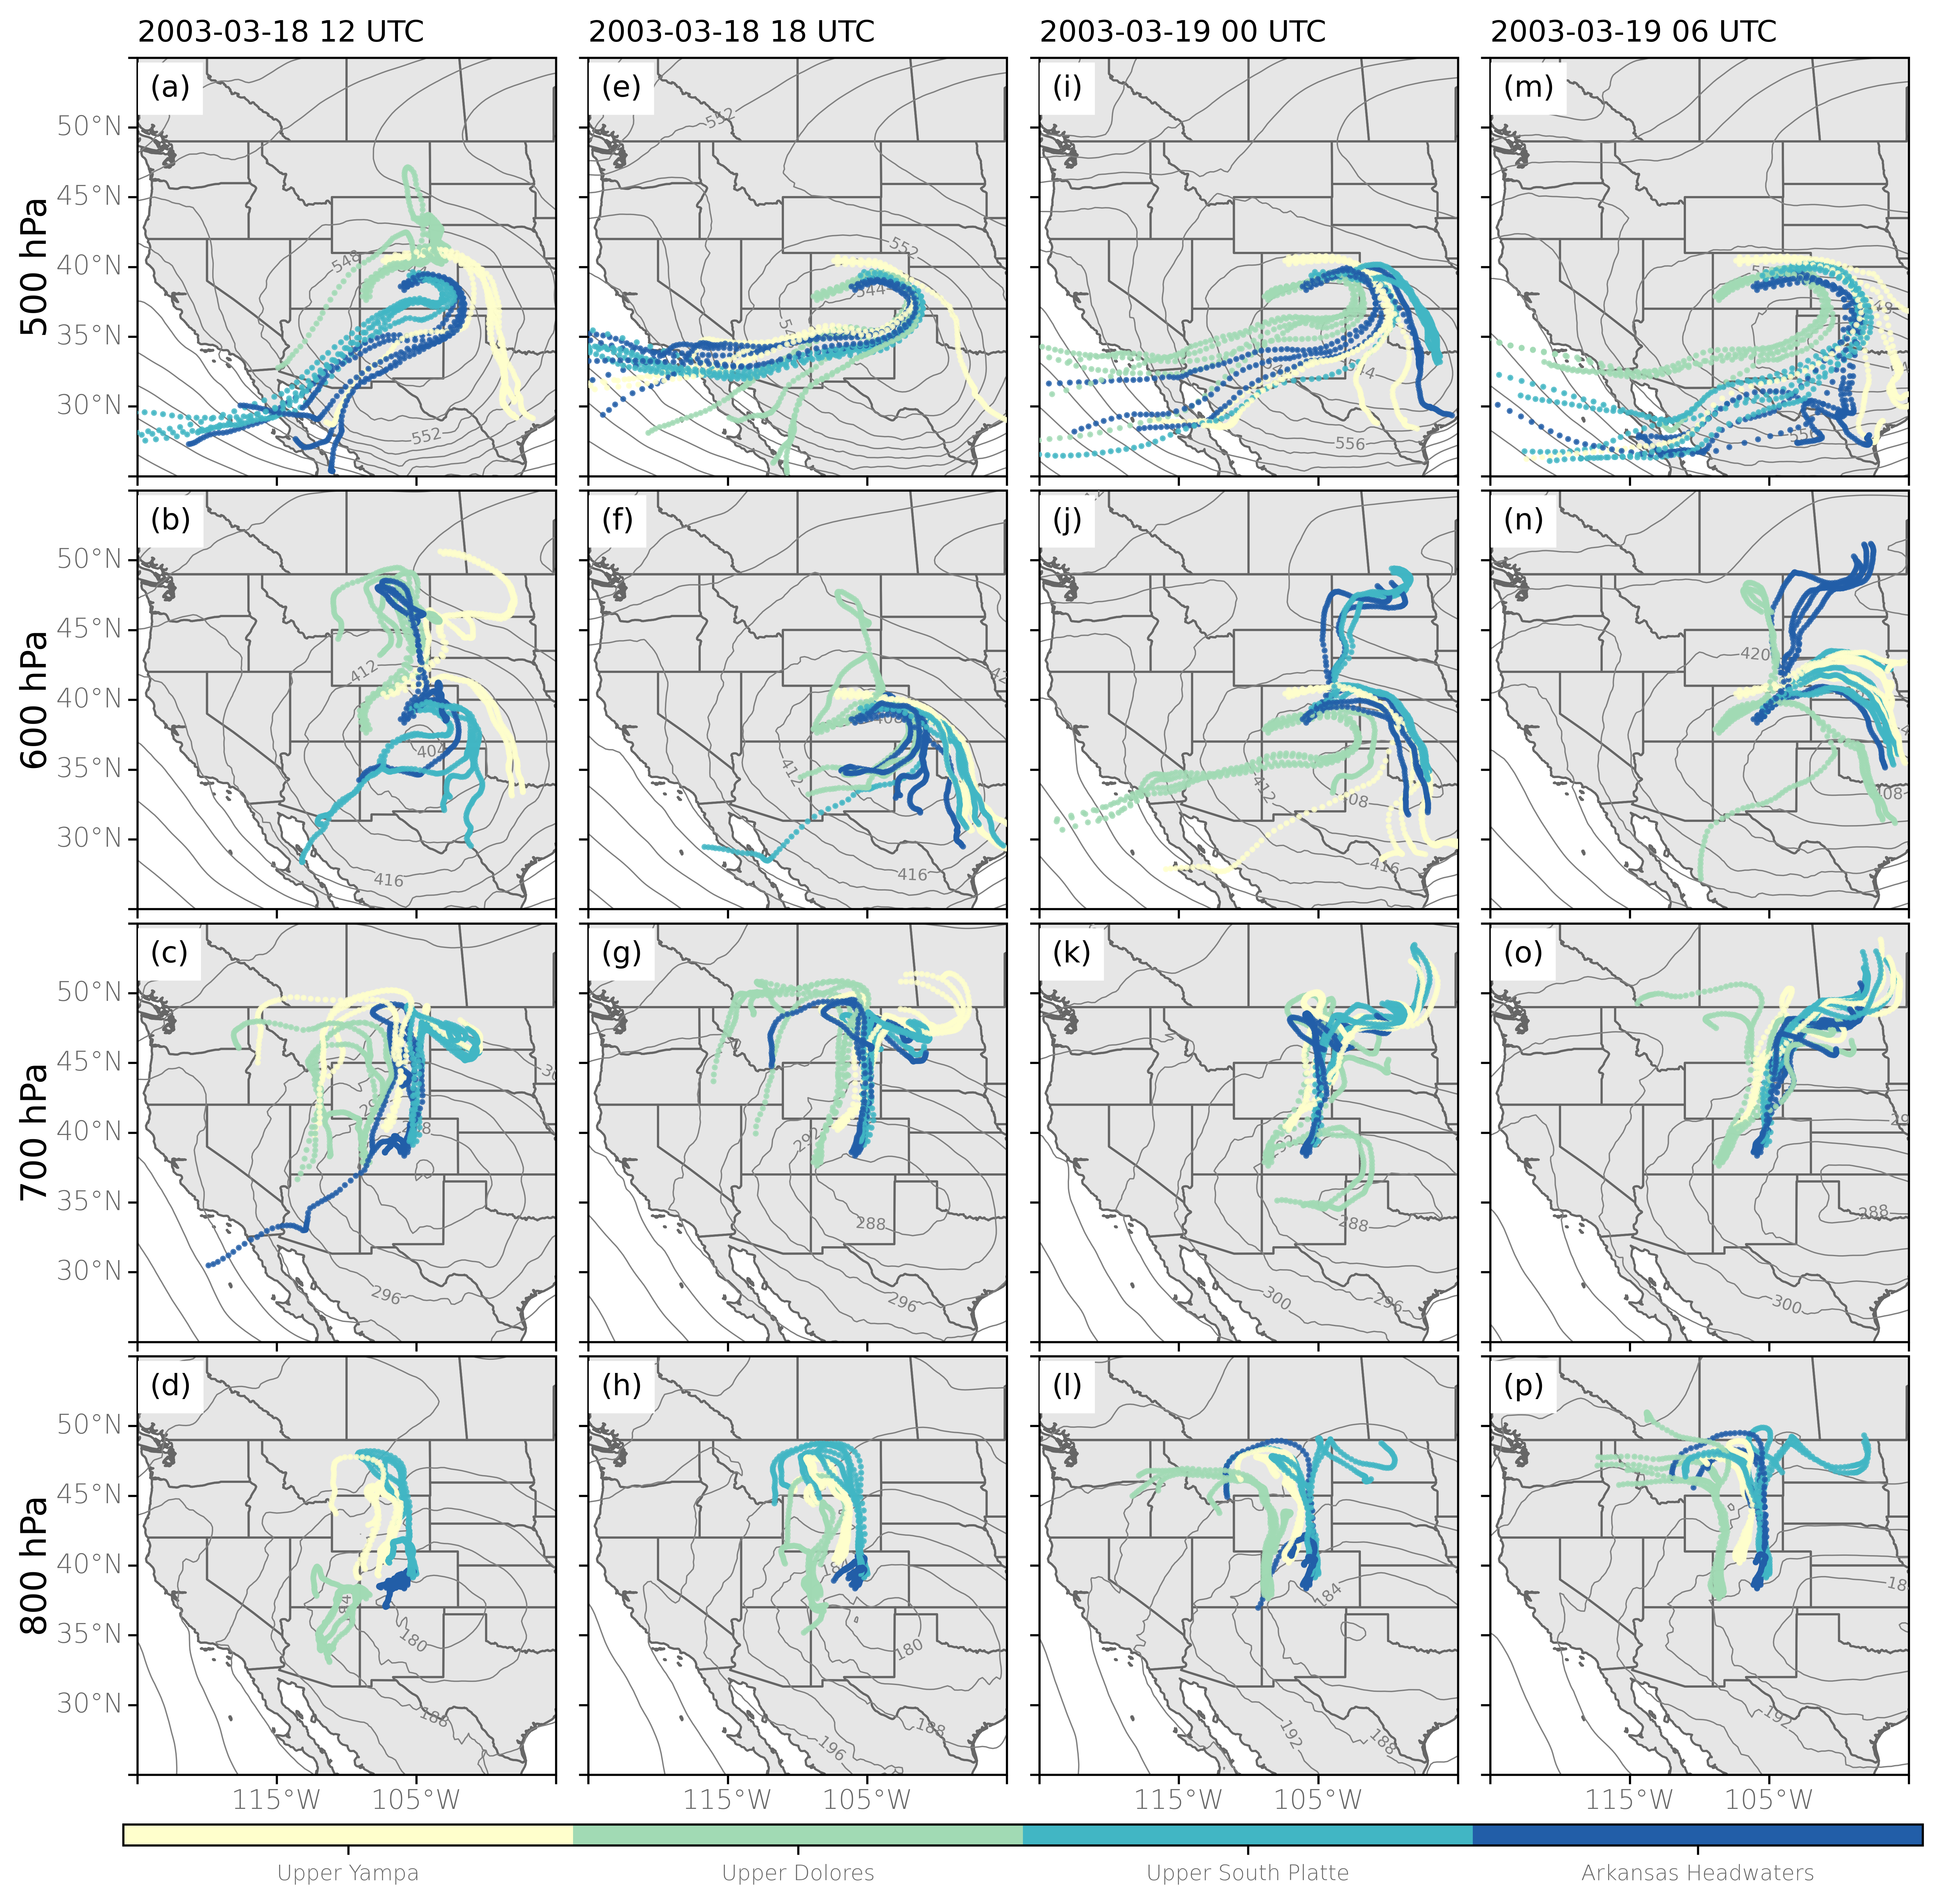

In [12]:
ext = [-130., -90., 20., 60.] # original submitted
ext = [-125., -95., 25., 55.]

fmt = 'png'
nrows = 6
ncols = 4
colors = ['#ffffcc', '#a1dab4', '#41b6c4', '#225ea8']

# Set up projection
datacrs = ccrs.PlateCarree()  ## the projection the data is in
mapcrs = ccrs.PlateCarree() ## the projection you want your map displayed in

# Set tick/grid locations
tx = 10
ty = 5
dx = np.arange(ext[0],ext[1]+tx,tx)
dy = np.arange(ext[2],ext[3]+ty,ty)

fig = plt.figure(figsize=(12.0 ,12.0))
fig.dpi = 600
fname = '../figs/sensitivity_test_trajectory_{0}'.format(storm)

## Use gridspec to set up a plot with a series of subplots that is
## n-rows by n-columns
gs = GridSpec(nrows, ncols, height_ratios=[1, 1, 1, 1, 0.05, 0.05], width_ratios = [1, 1, 1, 1], wspace=0.01, hspace=0.05)
## use gs[rows index, columns index] to access grids

left_lats = [True, False, False, False]
letter_idx = np.arange(0,16, 4)
## each 6 hours gets its own plot
for i, start_date_val in enumerate(tmp.start_date.values):
    
    for j, lev_val in enumerate(tmp.start_lev.values):
        print(i, j, lev_val)
        ax = fig.add_subplot(gs[j, i], projection=mapcrs)
        ax = draw_basemap(ax, extent=ext, xticks=dx, yticks=dy,left_lats=left_lats[i], right_lats=False)
        ax.set_extent(ext, datacrs)
        ax.add_feature(cfeature.STATES, edgecolor='0.4', linewidth=0.8)

        ## add geopotential height contours
        gph_data = gph.sel(valid_time=start_date_val, pressure_level=lev_val)
        clevs_hgts = np.arange(0,8000,4)
        z = gph_data.z.values / 9.80665 # convert from geopotential to geopotential height in m
        cs = ax.contour(gph.longitude.values, gph.latitude.values, z/10., transform=datacrs,
                    levels=clevs_hgts, colors='grey', linewidths=0.5)
        plt.clabel(cs, fmt='%d',fontsize=6, inline_spacing=5)  
        
        if j == 0:
            ax.set_title(t_lst[i], loc='left', fontsize=11)

        if i == 0: # add row labels to the far left plot
            ax.text(-0.20, 0.5, '{0} hPa'.format(str(int(lev_val))), va='bottom', ha='center',
                rotation='vertical', rotation_mode='anchor', fontsize=13,
                transform=ax.transAxes)
            
        ## start with start date and level
        data = tmp.sel(start_lev=lev_val, start_date=start_date_val)
        
        # need this to fix annotate transform
        transform = datacrs._as_mpl_transform(ax)
        ## Loop through grid
        for k, grid_val in enumerate(data.grid.values):
            for m, HUC8 in enumerate(data.HUC8.values):
                d = data.sel(grid=grid_val, HUC8=HUC8)
                y_lst = d.latitude.values
                x_lst = d.longitude.values
                # z_lst = d.level.values
                z_lst = d.q.values
                # cmap, norm, bnds = ccmaps.cmap('pressure')
                cf = ax.scatter(x_lst, y_lst, c=colors[m], marker='.', transform=datacrs, alpha=0.8, s=6, zorder=100)
                # cf = ax.scatter(x_lst, y_lst, c=z_lst, marker='.', transform=datacrs, alpha=0.8, s=6, zorder=100)

        ## add in four focus watersheds
        # polys.plot(ax=ax, edgecolor='white', color='None', zorder=99)
        col = letter_idx[i]
        titlestring = '({0})'.format(letter_lst[col+j])
        ax.text(0.03, 0.96, titlestring, ha='left', va='top', transform=ax.transAxes, fontsize=11., backgroundcolor='white', zorder=101)
    
        
# Add color bar
cbax = plt.subplot(gs[-1,:]) # colorbar axis
plot_sensitivity_cbar(cbax, orientation='horizontal')
kw_ticklabels = {'size': 8, 'color': 'dimgray', 'weight': 'light'}
cbax.set_xticklabels(HUC8_lbl, **kw_ticklabels)  # horizontally oriented colorbar
# cb = Colorbar(ax = cbax, mappable = cf, orientation = 'horizontal', ticklocation = 'bottom')
# cb.set_label('Specific Humidity (kg kg$^{-1}$)', fontsize=11)
# cb.ax.tick_params(labelsize=12)

fig.savefig('%s.%s' %(fname, fmt), bbox_inches='tight', dpi=fig.dpi, transparent=True)
plt.show()
fig.clf()